In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [4]:
df["Country"] = "Kenya"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

In [5]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


In [6]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

Duplicate rows found: 0


In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


In [8]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [9]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


In [10]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN","PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = np.abs(z_scores) > 3

print("Outlier rows:", outliers.any(axis=1).sum())

Outlier rows: 121


In [11]:
for col in cols:
    mean = df[col].mean()
    std = df[col].std()

    upper = mean + 3 * std
    lower = mean - 3 * std
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [12]:
df[cols].head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,19.56,28.99,12.09,0.00,45.32,3.12,4.76
1,19.63,29.77,11.04,0.00,38.76,3.23,4.35
2,20.40,30.57,11.71,0.00,41.75,3.46,4.68
3,21.33,31.20,13.02,3.49,51.87,2.29,4.00
4,20.41,29.52,12.38,1.79,48.04,1.77,4.05


In [13]:
df = df.sort_values("Date")
df = df.ffill()

In [14]:
df = df.dropna(thresh=int(0.7 * df.shape[1]))

In [15]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427483,27.839233,14.674660,13.165548,1.323742,65.851564,3.061765,4.375240,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,16.105128,20.762407,10.426097,4.110000,0.000000,36.042768,0.610000,1.398774,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,24.750071,34.270000,18.750000,20.120000,11.008847,91.070000,5.280000,7.351708,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.438281,2.357038,1.410642,2.605174,2.282832,9.913635,0.853218,0.991732,0.126391,1.607151,NaN,3.477046


In [16]:
df.to_csv("../data/kenya_clean.csv", index=False)

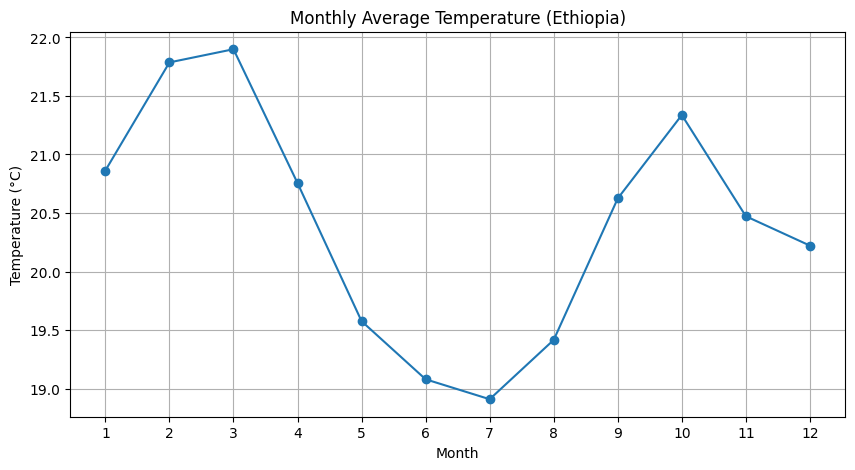

In [17]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

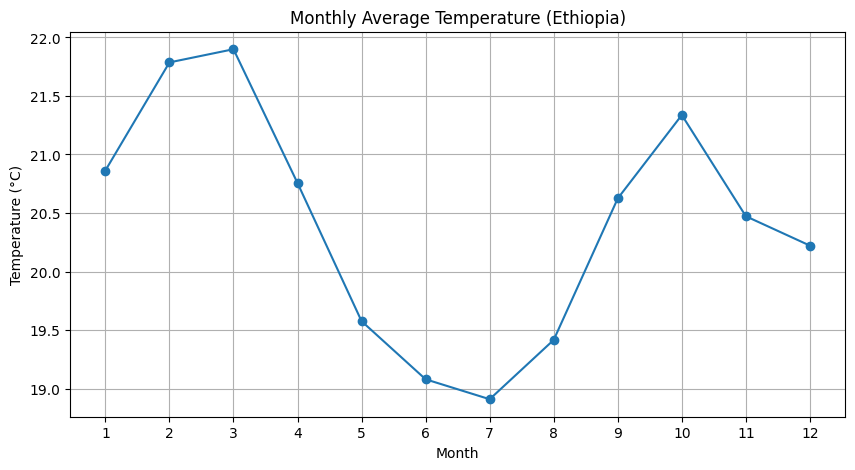

In [18]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (Ethiopia)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

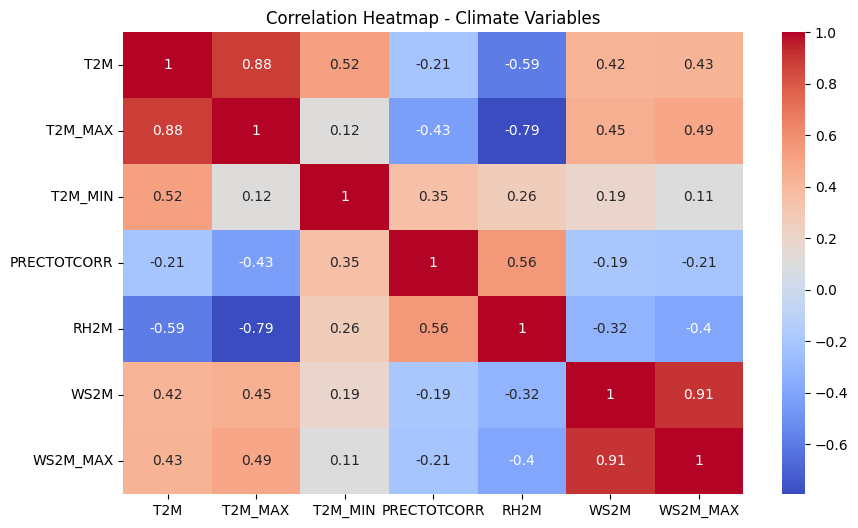

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Climate Variables")
plt.show()

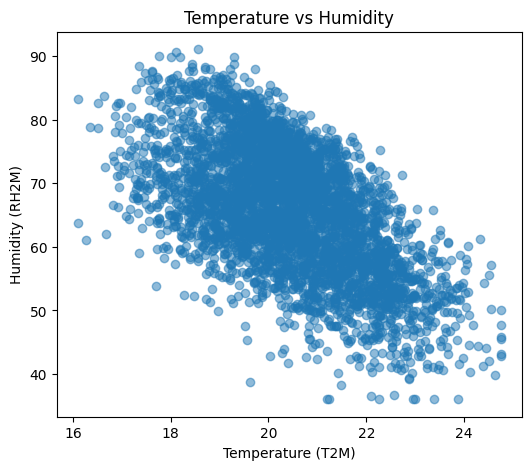

In [20]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

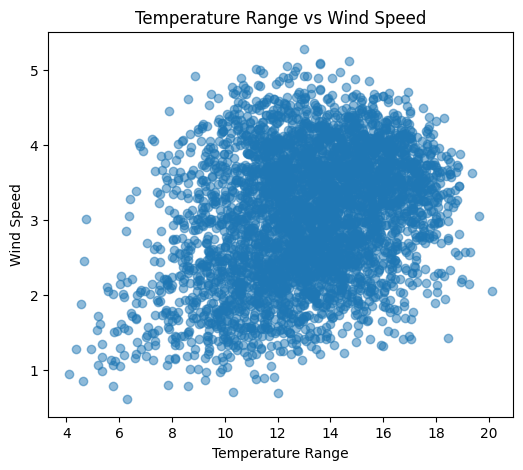

In [21]:
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()

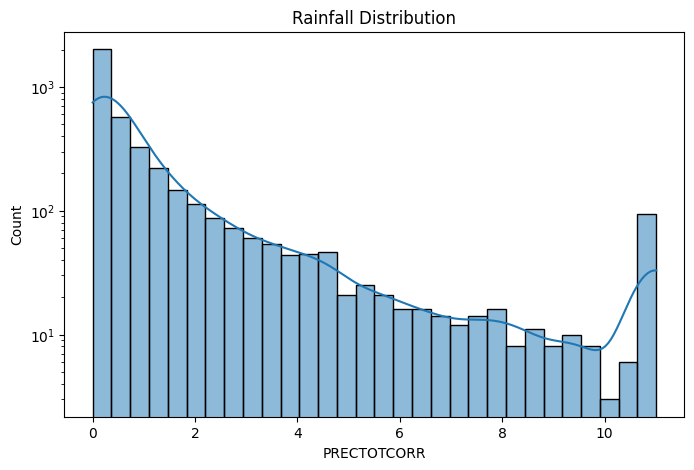

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Rainfall Distribution")
plt.yscale("log")  # helps if skewed
plt.show()